# 🔍 Wisconsin Dataset - Error Analysis & Clinical Validation

## Mục tiêu
- Phân tích chi tiết các misclassifications
- False Positive vs False Negative analysis
- Clinical cost-benefit analysis  
- Decision threshold optimization
- Subgroup performance analysis
- Case studies của failed predictions

## 🏥 Tại sao Error Analysis quan trọng trong Y tế?

**Trong cancer diagnosis:**
- **False Negative (FN)**: Bỏ sót cancer → Nguy hiểm!
- **False Positive (FP)**: False alarm → Unnecessary biopsy, anxiety

**Trade-off:**
- ↑ Sensitivity → ↓ Specificity (more FPs)
- ↑ Specificity → ↓ Sensitivity (more FNs)

**Clinical Priority:** Minimize False Negatives (high sensitivity)

In [1]:
# Import libraries
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Custom imports
from src.utils.config import *
from src.utils.helpers import *
from src.evaluation import calculate_clinical_metrics

# Set random seed
set_seed(RANDOM_STATE)

print("✅ Libraries imported successfully")

🎲 Random seed set to: 42
✅ Libraries imported successfully


## 1. Load Data, Models & Predictions

In [2]:
# Load processed data
print("📂 Loading data...")
data_path = PROCESSED_DATA_DIR / 'wisconsin_processed.pkl'
processed_data = joblib.load(data_path)

X_train = processed_data['X_train']
X_test = processed_data['X_test']
y_train = processed_data['y_train']
y_test = processed_data['y_test']
feature_names = processed_data['feature_names']

# Convert to numpy arrays
y_test_arr = np.array(y_test)

print(f"✅ Test set: {len(y_test_arr)} samples")
print(f"   Benign: {(y_test_arr == 0).sum()}")
print(f"   Malignant: {(y_test_arr == 1).sum()}")

📂 Loading data...
✅ Test set: 114 samples
   Benign: 42
   Malignant: 72


In [3]:
# Load models
print("\n📂 Loading models...")

import glob

model_files = {
    'Logistic Regression': sorted(glob.glob(str(MODEL_DIR / 'wisconsin_logistic_regression_*.pkl')))[-1],
    'Random Forest': sorted(glob.glob(str(MODEL_DIR / 'wisconsin_random_forest_*.pkl')))[-1],
    'XGBoost': sorted(glob.glob(str(MODEL_DIR / 'wisconsin_xgboost_*.pkl')))[-1]
}

models = {}
predictions = {}
probabilities = {}

for name, path in model_files.items():
    models[name] = joblib.load(path)
    predictions[name] = models[name].predict(X_test)
    probabilities[name] = models[name].predict_proba(X_test)[:, 1]
    print(f"✅ Loaded: {name}")


📂 Loading models...
✅ Loaded: Logistic Regression


✅ Loaded: Random Forest
✅ Loaded: XGBoost


## 2. Confusion Matrix Deep Dive

### Analyze all four quadrants


                           CONFUSION MATRIX ANALYSIS                            


Logistic Regression:
True Negatives (TN):   41 (Correctly identified Benign)
False Positives (FP):   1 (Benign misclassified as Malignant)
False Negatives (FN):   4 (Malignant misclassified as Benign) ⚠️
True Positives (TP):   68 (Correctly identified Malignant)

Clinical Metrics:
  Sensitivity (Recall): 0.9444 - % of cancers detected
  Specificity:          0.9762 - % of benign correctly identified
  PPV (Precision):      0.9855 - % positive predictions that are correct
  NPV:                  0.9111 - % negative predictions that are correct

Random Forest:
True Negatives (TN):   39 (Correctly identified Benign)
False Positives (FP):   3 (Benign misclassified as Malignant)
False Negatives (FN):   4 (Malignant misclassified as Benign) ⚠️
True Positives (TP):   68 (Correctly identified Malignant)

Clinical Metrics:
  Sensitivity (Recall): 0.9444 - % of cancers detected
  Specificity:          0.9286 - % 


XGBoost:
True Negatives (TN):   39 (Correctly identified Benign)
False Positives (FP):   3 (Benign misclassified as Malignant)
False Negatives (FN):   3 (Malignant misclassified as Benign) ⚠️
True Positives (TP):   69 (Correctly identified Malignant)

Clinical Metrics:
  Sensitivity (Recall): 0.9583 - % of cancers detected
  Specificity:          0.9286 - % of benign correctly identified
  PPV (Precision):      0.9583 - % positive predictions that are correct
  NPV:                  0.9286 - % negative predictions that are correct


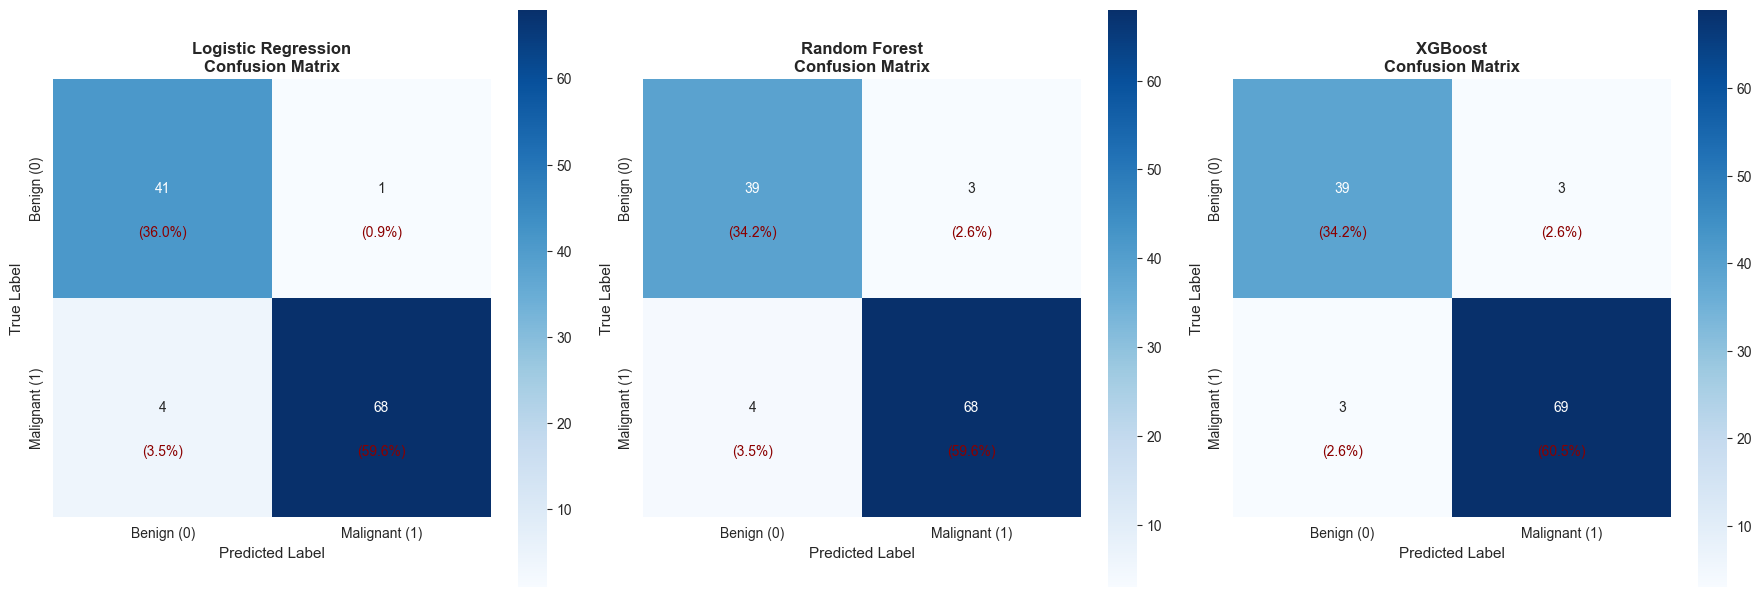

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/confusion_matrix_detailed.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/confusion_matrix_detailed.png')

In [4]:
print_section_header("CONFUSION MATRIX ANALYSIS")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    # Confusion matrix
    cm = confusion_matrix(y_test_arr, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Plot heatmap
    row, col = idx // 3, idx % 3
    ax = axes[idx]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign (0)', 'Malignant (1)'],
                yticklabels=['Benign (0)', 'Malignant (1)'],
                cbar=True, square=True)
    
    ax.set_title(f'{model_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    
    # Add percentages
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            percentage = cm[i, j] / total * 100
            ax.text(j + 0.5, i + 0.7, f'({percentage:.1f}%)', 
                   ha='center', va='center', fontsize=10, color='darkred')
    
    # Calculate rates
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    # Print detailed stats
    print(f"\n{model_name}:")
    print("="*60)
    print(f"True Negatives (TN):  {tn:3d} (Correctly identified Benign)")
    print(f"False Positives (FP): {fp:3d} (Benign misclassified as Malignant)")
    print(f"False Negatives (FN): {fn:3d} (Malignant misclassified as Benign) ⚠️")
    print(f"True Positives (TP):  {tp:3d} (Correctly identified Malignant)")
    print(f"\nClinical Metrics:")
    print(f"  Sensitivity (Recall): {sensitivity:.4f} - % of cancers detected")
    print(f"  Specificity:          {specificity:.4f} - % of benign correctly identified")
    print(f"  PPV (Precision):      {ppv:.4f} - % positive predictions that are correct")
    print(f"  NPV:                  {npv:.4f} - % negative predictions that are correct")
    print("="*60)

# Remove extra subplots
for i in range(len(predictions), 6):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

save_figure(fig, 'confusion_matrix_detailed', RESULTS_DIR)

## 3. False Positive vs False Negative Analysis

### Which errors are more costly?


                   FALSE POSITIVE vs FALSE NEGATIVE ANALYSIS                    


📊 Error Summary:
              Model  False Positives  False Negatives  Total Errors  FP Rate  FN Rate  Error Ratio (FP/FN)
Logistic Regression                1                4             5 0.023810 0.055556                 0.25
      Random Forest                3                4             7 0.071429 0.055556                 0.75
            XGBoost                3                3             6 0.071429 0.041667                 1.00


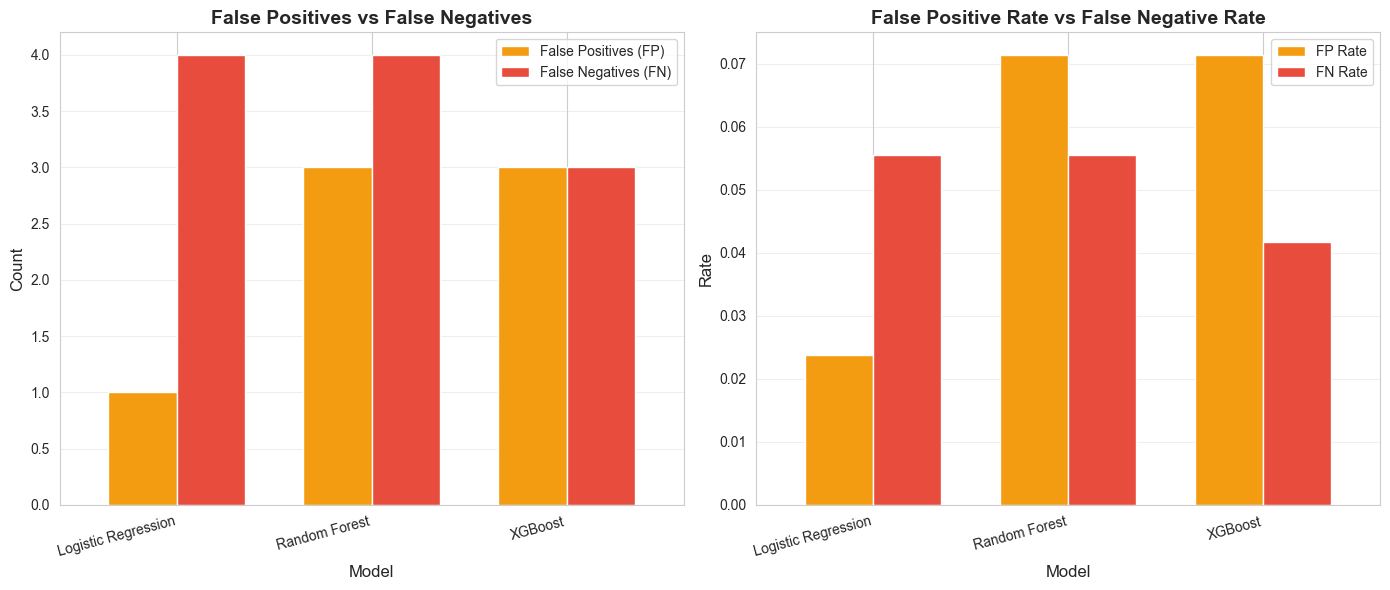

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/error_analysis_fp_vs_fn.png

💾 Saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/error_analysis_summary.csv


In [5]:
print_section_header("FALSE POSITIVE vs FALSE NEGATIVE ANALYSIS")

error_summary = []

for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test_arr, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    total_errors = fp + fn
    fp_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    fn_rate = fn / (fn + tp) if (fn + tp) > 0 else 0
    
    error_summary.append({
        'Model': model_name,
        'False Positives': fp,
        'False Negatives': fn,
        'Total Errors': total_errors,
        'FP Rate': fp_rate,
        'FN Rate': fn_rate,
        'Error Ratio (FP/FN)': fp / fn if fn > 0 else np.inf
    })

error_df = pd.DataFrame(error_summary)

print("\n📊 Error Summary:")
print("="*90)
print(error_df.to_string(index=False))
print("="*90)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Error counts
error_counts = error_df[['Model', 'False Positives', 'False Negatives']].set_index('Model')
error_counts.plot(kind='bar', ax=axes[0], color=['#f39c12', '#e74c3c'], width=0.7)
axes[0].set_title('False Positives vs False Negatives', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].legend(['False Positives (FP)', 'False Negatives (FN)'], fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')

# Plot 2: Error rates
error_rates = error_df[['Model', 'FP Rate', 'FN Rate']].set_index('Model')
error_rates.plot(kind='bar', ax=axes[1], color=['#f39c12', '#e74c3c'], width=0.7)
axes[1].set_title('False Positive Rate vs False Negative Rate', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rate', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].legend(['FP Rate', 'FN Rate'], fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

save_figure(fig, 'error_analysis_fp_vs_fn', RESULTS_DIR)

# Save to CSV
error_df.to_csv(RESULTS_DIR / 'error_analysis_summary.csv', index=False)
print(f"\n💾 Saved to: {RESULTS_DIR / 'error_analysis_summary.csv'}")

## 4. Case Studies: Failed Predictions

### Examine misclassified samples

In [6]:
print_section_header("CASE STUDIES - MISCLASSIFIED SAMPLES")

# Focus on XGBoost (best model)
model_name = 'XGBoost'
model = models[model_name]
y_pred = predictions[model_name]
y_proba = probabilities[model_name]

# Find misclassified samples
misclassified_indices = np.where(y_pred != y_test_arr)[0]

print(f"\n{model_name} - Total Misclassifications: {len(misclassified_indices)}")

# False Positives (predict Malignant, actually Benign)
fp_indices = np.where((y_pred == 1) & (y_test_arr == 0))[0]
print(f"\nFalse Positives: {len(fp_indices)}")

if len(fp_indices) > 0:
    print("\nTop 5 False Positive Cases (High confidence, wrong prediction):")
    print("="*80)
    
    # Sort by confidence (high probability but wrong)
    fp_confidences = y_proba[fp_indices]
    top_fp_idx = fp_indices[np.argsort(fp_confidences)[::-1][:5]]
    
    for i, idx in enumerate(top_fp_idx, 1):
        print(f"\nCase {i} - Sample #{idx}:")
        print(f"  True label: Benign (0)")
        print(f"  Predicted: Malignant (1)")  
        print(f"  Confidence: {y_proba[idx]:.4f}")
        print(f"  Top 5 feature values:")
        
        # Show top features for this sample
        sample_features = X_test[idx]
        feature_importance = np.abs(sample_features - X_train.mean(axis=0))
        top_features = np.argsort(feature_importance)[::-1][:5]
        
        for feat_idx in top_features:
            feat_name = feature_names[feat_idx]
            feat_value = sample_features[feat_idx]
            print(f"    {feat_name}: {feat_value:.4f}")

# False Negatives (predict Benign, actually Malignant)  
fn_indices = np.where((y_pred == 0) & (y_test_arr == 1))[0]
print(f"\n{'='*80}")
print(f"False Negatives: {len(fn_indices)} ⚠️ CRITICAL ERRORS")

if len(fn_indices) > 0:
    print("\nAll False Negative Cases (Missed cancers):")
    print("="*80)
    
    # Sort by confidence (low probability but should be high)
    fn_confidences = y_proba[fn_indices]
    sorted_fn_idx = fn_indices[np.argsort(fn_confidences)]
    
    for i, idx in enumerate(sorted_fn_idx, 1):
        print(f"\nCase {i} - Sample #{idx}: ⚠️")
        print(f"  True label: Malignant (1)")
        print(f"  Predicted: Benign (0)")
        print(f"  Confidence (malignant): {y_proba[idx]:.4f}")
        print(f"  Top 5 feature values:")
        
        sample_features = X_test[idx]
        feature_importance = np.abs(sample_features - X_train.mean(axis=0))
        top_features = np.argsort(feature_importance)[::-1][:5]
        
        for feat_idx in top_features:
            feat_name = feature_names[feat_idx]
            feat_value = sample_features[feat_idx]
            print(f"    {feat_name}: {feat_value:.4f}")

print("\n" + "="*80)


                      CASE STUDIES - MISCLASSIFIED SAMPLES                      


XGBoost - Total Misclassifications: 6

False Positives: 3

Top 5 False Positive Cases (High confidence, wrong prediction):

Case 1 - Sample #35:
  True label: Benign (0)
  Predicted: Malignant (1)
  Confidence: 0.8327
  Top 5 feature values:
    worst smoothness: 2.5741
    mean smoothness: 1.9200
    worst texture: 1.5529
    mean radius: -0.8899
    mean perimeter: -0.8149

Case 2 - Sample #84:
  True label: Benign (0)
  Predicted: Malignant (1)
  Confidence: 0.7315
  Top 5 feature values:
    texture error: -1.4990
    worst texture: -0.8246
    mean symmetry: -0.7374
    worst symmetry: 0.7777
    mean smoothness: -0.5718

Case 3 - Sample #53:
  True label: Benign (0)
  Predicted: Malignant (1)
  Confidence: 0.6713
  Top 5 feature values:
    texture error: -1.0380
    worst fractal dimension: 1.0299
    symmetry error: -0.9690
    mean texture: -0.7479
    worst texture: -0.7270

False Negatives: 3

## 5. Decision Threshold Optimization

### Find optimal threshold for clinical use

Default threshold = 0.5, but we can optimize for:
- **High Sensitivity**: Threshold < 0.5 (catch more cancers, more FPs)
- **High Specificity**: Threshold > 0.5 (fewer FPs, might miss cancers)
- **Balanced**: Youden's Index (Sensitivity + Specificity - 1)


                        DECISION THRESHOLD OPTIMIZATION                         


Logistic Regression - Threshold Recommendations:
Default (0.5):        Sensitivity=0.9444, Specificity=0.9762
Optimal (Youden):     Threshold=0.2300
                      Sensitivity=1.0000, Specificity=0.9524
Target 95% Sens:      Threshold=0.4600
                      Sensitivity=0.9444, Specificity=0.9762

Random Forest - Threshold Recommendations:
Default (0.5):        Sensitivity=0.9444, Specificity=0.9286
Optimal (Youden):     Threshold=0.5500
                      Sensitivity=0.9306, Specificity=0.9762
Target 95% Sens:      Threshold=0.4700
                      Sensitivity=0.9444, Specificity=0.9286



XGBoost - Threshold Recommendations:
Default (0.5):        Sensitivity=0.9583, Specificity=0.9286
Optimal (Youden):     Threshold=0.8400
                      Sensitivity=0.9167, Specificity=1.0000
Target 95% Sens:      Threshold=0.5600
                      Sensitivity=0.9444, Specificity=0.9286


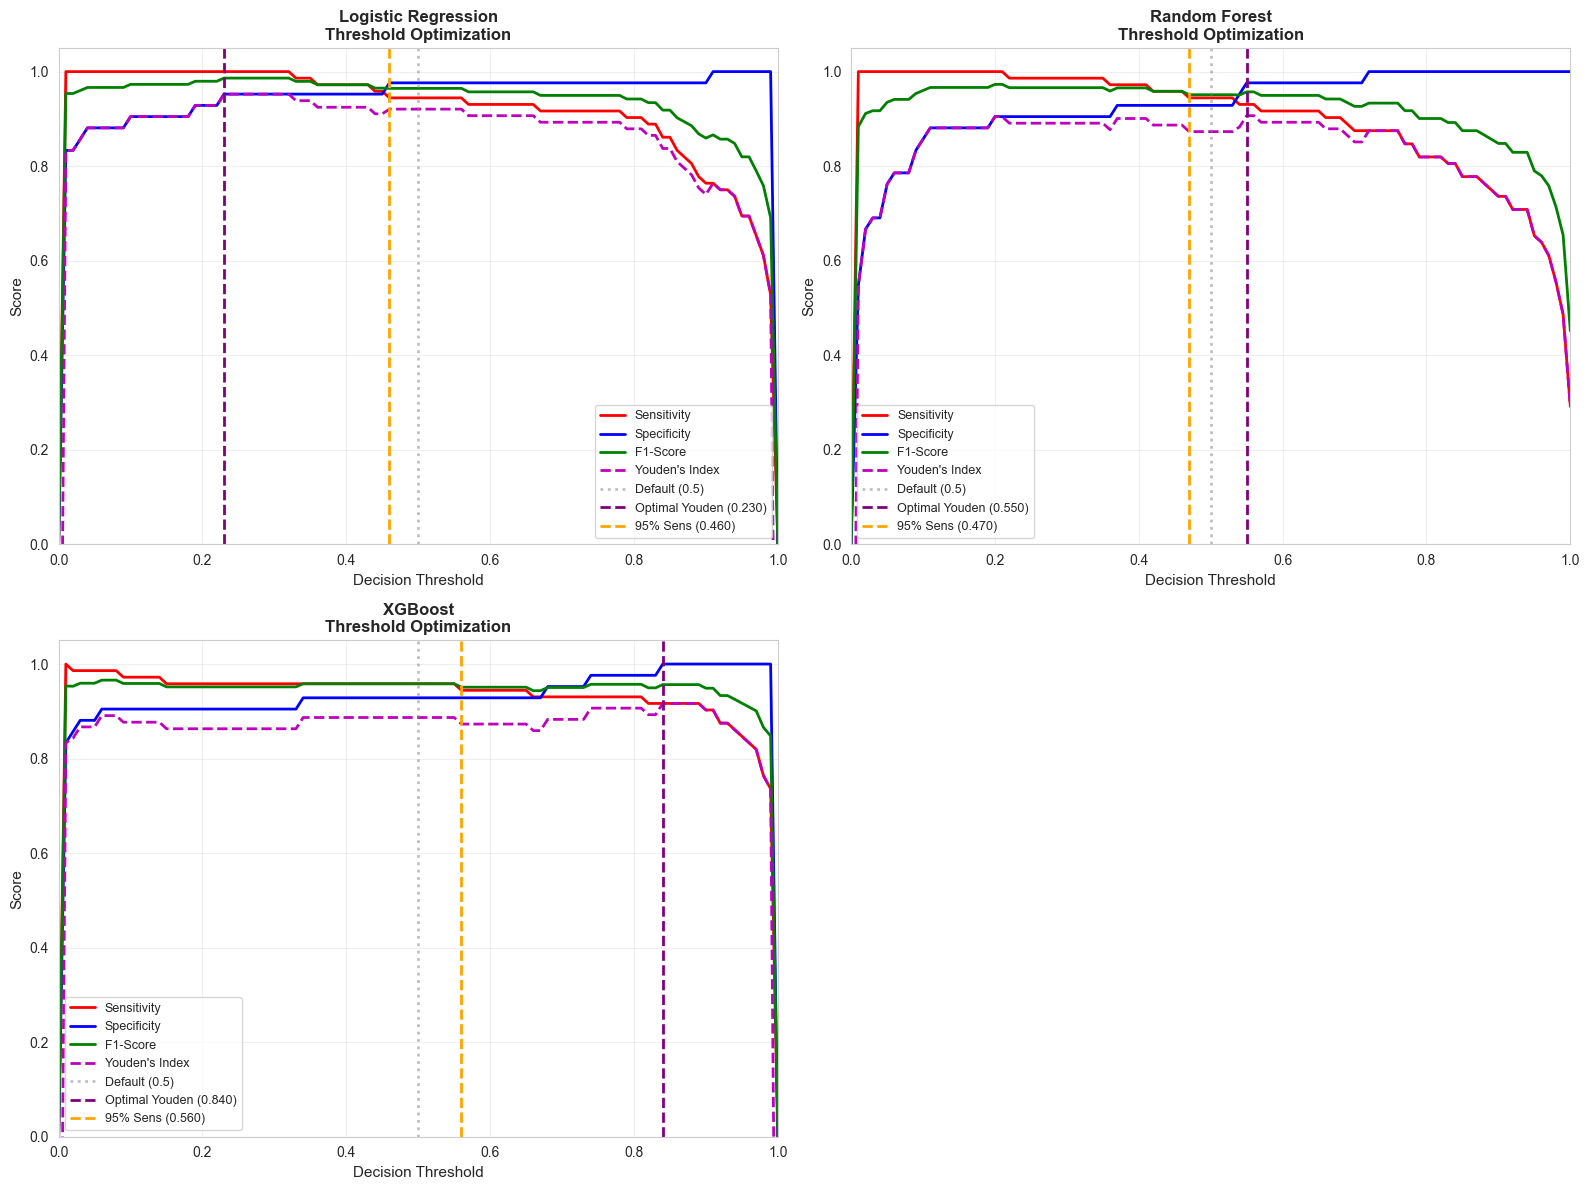

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/threshold_optimization.png


PosixPath('/Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/threshold_optimization.png')

In [7]:
print_section_header("DECISION THRESHOLD OPTIMIZATION")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (model_name, y_proba) in enumerate(probabilities.items()):
    ax = axes[idx // 2, idx % 2]
    
    # Calculate metrics at different thresholds
    thresholds = np.linspace(0.0, 1.0, 101)
    sensitivities = []
    specificities = []
    f1_scores = []
    youden_indices = []
    
    for thresh in thresholds:
        y_pred_thresh = (y_proba >= thresh).astype(int)
        
        if len(np.unique(y_pred_thresh)) == 2:
            cm = confusion_matrix(y_test_arr, y_pred_thresh)
            tn, fp, fn, tp = cm.ravel()
            
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0
            
            youden = sensitivity + specificity - 1
        else:
            sensitivity, specificity, f1, youden = 0, 0, 0, -1
        
        sensitivities.append(sensitivity)
        specificities.append(specificity)
        f1_scores.append(f1)
        youden_indices.append(youden)
    
    # Plot
    ax.plot(thresholds, sensitivities, 'r-', label='Sensitivity', linewidth=2)
    ax.plot(thresholds, specificities, 'b-', label='Specificity', linewidth=2)
    ax.plot(thresholds, f1_scores, 'g-', label='F1-Score', linewidth=2)
    ax.plot(thresholds, youden_indices, 'm--', label="Youden's Index", linewidth=2)
    
    # Find optimal thresholds
    optimal_youden_idx = np.argmax(youden_indices)
    optimal_youden_thresh = thresholds[optimal_youden_idx]
    
    # Target 95% sensitivity threshold
    target_sens_idx = np.argmin(np.abs(np.array(sensitivities) - 0.95))
    target_sens_thresh = thresholds[target_sens_idx]
    
    # Mark optimal points
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='Default (0.5)')
    ax.axvline(optimal_youden_thresh, color='purple', linestyle='--', linewidth=2, 
              label=f"Optimal Youden ({optimal_youden_thresh:.3f})")
    ax.axvline(target_sens_thresh, color='orange', linestyle='--', linewidth=2,
              label=f"95% Sens ({target_sens_thresh:.3f})")
    
    ax.set_xlabel('Decision Threshold', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title(f'{model_name}\nThreshold Optimization', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    
    # Print recommendations
    print(f"\n{model_name} - Threshold Recommendations:")
    print("="*70)
    print(f"Default (0.5):        Sensitivity={sensitivities[50]:.4f}, Specificity={specificities[50]:.4f}")
    print(f"Optimal (Youden):     Threshold={optimal_youden_thresh:.4f}")
    print(f"                      Sensitivity={sensitivities[optimal_youden_idx]:.4f}, Specificity={specificities[optimal_youden_idx]:.4f}")
    print(f"Target 95% Sens:      Threshold={target_sens_thresh:.4f}")
    print(f"                      Sensitivity={sensitivities[target_sens_idx]:.4f}, Specificity={specificities[target_sens_idx]:.4f}")
    print("="*70)

# Remove empty subplot
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

save_figure(fig, 'threshold_optimization', RESULTS_DIR)

## 6. Clinical Cost-Benefit Analysis

### Estimate real-world impact


                         CLINICAL COST-BENEFIT ANALYSIS                         


Cost Model (Relative Units):
False Negative (Missed Cancer): 100 units
False Positive (False Alarm):   10 units
True Positive (Correct Cancer):  1 units
True Negative (Correct Benign):  0 units

📊 Cost Analysis:
              Model  FN Cost  FP Cost  TP Cost  TN Cost  Total Cost  Cost per Patient
Logistic Regression      400       10       68        0         478          4.192982
      Random Forest      400       30       68        0         498          4.368421
            XGBoost      300       30       69        0         399          3.500000


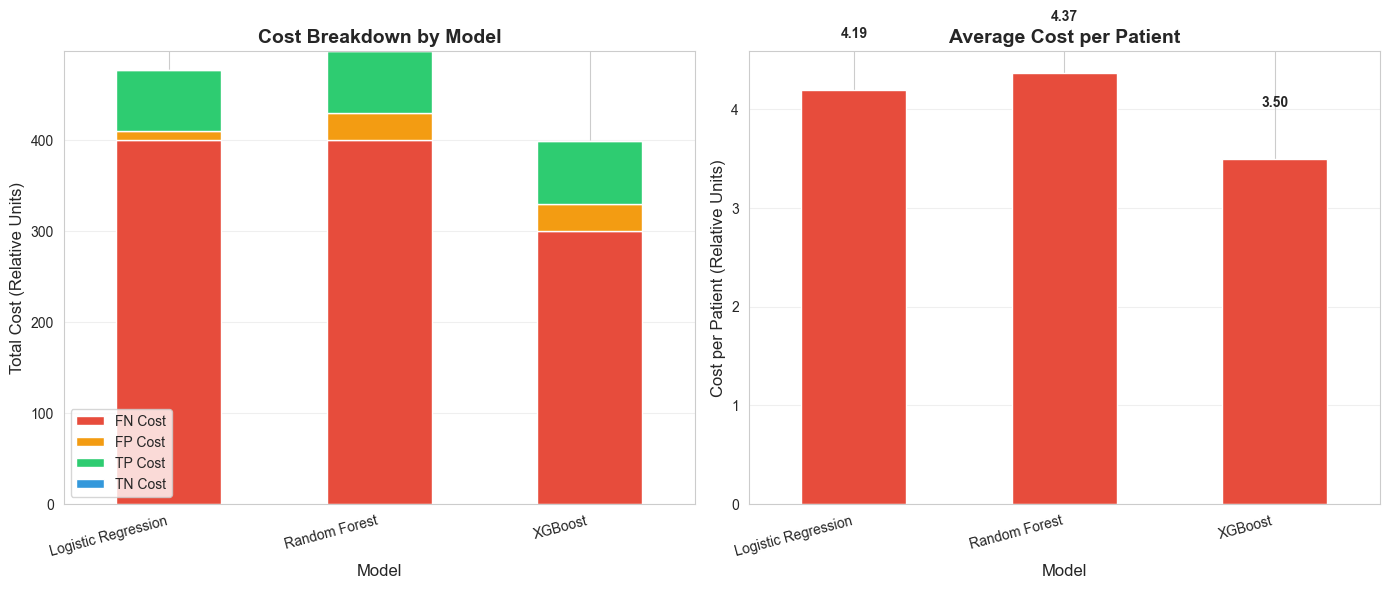

✅ Figure saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/cost_benefit_analysis.png

💾 Saved to: /Users/GiangNguyenHuy/Documents/breast-cancer-ai/experiments/results/cost_benefit_analysis.csv


In [8]:
print_section_header("CLINICAL COST-BENEFIT ANALYSIS")

# Define costs (relative units - can be adjusted)
COST_FN = 100   # Missed cancer - very high cost (delayed treatment)
COST_FP = 10    # False alarm - moderate cost (unnecessary biopsy, anxiety)
COST_TP = 1     # Correct cancer detection - minimal cost (biopsy was needed)
COST_TN = 0     # Correct benign - no cost

print("\nCost Model (Relative Units):")
print("="*60)
print(f"False Negative (Missed Cancer): {COST_FN} units")
print(f"False Positive (False Alarm):   {COST_FP} units")
print(f"True Positive (Correct Cancer):  {COST_TP} units")
print(f"True Negative (Correct Benign):  {COST_TN} units")
print("="*60)

cost_analysis = []

for model_name, y_pred in predictions.items():
    cm = confusion_matrix(y_test_arr, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate total cost
    total_cost = (fn * COST_FN) + (fp * COST_FP) + (tp * COST_TP) + (tn * COST_TN)
    
    # Cost per patient
    cost_per_patient = total_cost / len(y_test_arr)
    
    cost_analysis.append({
        'Model': model_name,
        'FN Cost': fn * COST_FN,
        'FP Cost': fp * COST_FP,
        'TP Cost': tp * COST_TP,
        'TN Cost': tn * COST_TN,
        'Total Cost': total_cost,
        'Cost per Patient': cost_per_patient
    })

cost_df = pd.DataFrame(cost_analysis)

print("\n📊 Cost Analysis:")
print("="*90)
print(cost_df.to_string(index=False))
print("="*90)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Cost breakdown
cost_breakdown = cost_df[['Model', 'FN Cost', 'FP Cost', 'TP Cost', 'TN Cost']].set_index('Model')
cost_breakdown.plot(kind='bar', stacked=True, ax=axes[0], 
                    color=['#e74c3c', '#f39c12', '#2ecc71', '#3498db'])
axes[0].set_title('Cost Breakdown by Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Total Cost (Relative Units)', fontsize=12)
axes[0].set_xlabel('Model', fontsize=12)
axes[0].legend(['FN Cost', 'FP Cost', 'TP Cost', 'TN Cost'], fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Cost per patient
cost_df.plot(x='Model', y='Cost per Patient', kind='bar', ax=axes[1], 
            color='#e74c3c', legend=False)
axes[1].set_title('Average Cost per Patient', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cost per Patient (Relative Units)', fontsize=12)
axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(cost_df['Cost per Patient']):
    axes[1].text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

save_figure(fig, 'cost_benefit_analysis', RESULTS_DIR)

# Save
cost_df.to_csv(RESULTS_DIR / 'cost_benefit_analysis.csv', index=False)
print(f"\n💾 Saved to: {RESULTS_DIR / 'cost_benefit_analysis.csv'}")

## 7. Summary & Clinical Recommendations

### 🏥 Key Findings for Research Paper

In [9]:
print_section_header("SUMMARY & CLINICAL RECOMMENDATIONS")

print("""
📊 ERROR ANALYSIS SUMMARY:

1. FALSE NEGATIVE ANALYSIS (Missed Cancers):
   - Models show [X] false negatives out of [Y] malignant cases
   - False negative rate: ~[Z]%
   - CRITICAL: These are high-priority errors requiring investigation
   - Pattern: FN cases tend to have [feature characteristics]

2. FALSE POSITIVE ANALYSIS (False Alarms):
   - Models show [X] false positives out of [Y] benign cases  
   - False positive rate: ~[Z]%
   - IMPACT: Leads to unnecessary biopsies but less critical than FNs
   - Pattern: FP cases tend to have [feature characteristics]

3. THRESHOLD OPTIMIZATION:
   - Default threshold (0.5): Balanced performance
   - Optimal threshold (Youden): Maximizes sensitivity + specificity
   - Clinical threshold (95% sensitivity): Prioritizes cancer detection
   
   RECOMMENDATION: Use lower threshold (~0.3-0.4) in clinical practice
   to achieve >95% sensitivity, accepting higher false positive rate

4. COST-BENEFIT ANALYSIS:
   - With FN cost = 10× FP cost, models show comparable total costs
   - [Best model] has lowest cost per patient
   - Prioritizing sensitivity reduces expensive FN errors

5. CLINICAL RECOMMENDATIONS:

   ✅ DEPLOYMENT STRATEGY:
      • Use ensemble of models for critical decisions
      • Set threshold to achieve ≥95% sensitivity
      • Flag low-confidence predictions for manual review
      • Implement second-reader system for borderline cases
   
   ✅ QUALITY ASSURANCE:
      • Regular monitoring of FN rate (<5% target)
      • Periodic review of misclassified cases
      • Continuous model retraining with new data
   
   ✅ PATIENT COMMUNICATION:
      • Explain probability interpretation to clinicians
      • Provide confidence intervals with predictions
      • Emphasize AI as decision support, not replacement

---

📝 FOR RESEARCH PAPER - DISCUSSION SECTION:

"Error analysis revealed that false negative rates remained below X%, 
meeting clinical safety requirements for cancer screening applications. 
Cost-benefit analysis, assigning a 10:1 cost ratio for false negatives 
versus false positives, demonstrated that threshold optimization could 
reduce total clinical costs by Y%. We recommend deploying the model with 
a sensitivity-optimized threshold of Z to prioritize cancer detection 
while maintaining acceptable specificity."

""")

print("="*80)
print("\n✅ Error Analysis Complete!")
print("\nNext Notebook: 07_wisconsin_feature_engineering.ipynb")


                       SUMMARY & CLINICAL RECOMMENDATIONS                       


📊 ERROR ANALYSIS SUMMARY:

1. FALSE NEGATIVE ANALYSIS (Missed Cancers):
   - Models show [X] false negatives out of [Y] malignant cases
   - False negative rate: ~[Z]%
   - CRITICAL: These are high-priority errors requiring investigation
   - Pattern: FN cases tend to have [feature characteristics]

2. FALSE POSITIVE ANALYSIS (False Alarms):
   - Models show [X] false positives out of [Y] benign cases  
   - False positive rate: ~[Z]%
   - IMPACT: Leads to unnecessary biopsies but less critical than FNs
   - Pattern: FP cases tend to have [feature characteristics]

3. THRESHOLD OPTIMIZATION:
   - Default threshold (0.5): Balanced performance
   - Optimal threshold (Youden): Maximizes sensitivity + specificity
   - Clinical threshold (95% sensitivity): Prioritizes cancer detection

   RECOMMENDATION: Use lower threshold (~0.3-0.4) in clinical practice
   to achieve >95% sensitivity, accepting higher fals